# DATASET SACADO DE KAGGLE (https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores)

In [33]:
# Librerías
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()

# Configurar visualización amplia 
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(700)
pl.Config.set_fmt_str_lengths(150)
pl.Config.set_tbl_rows(10)

polars.config.Config

### Cargamos el Dataset como LazyFrame

In [34]:
# Install dependencies as needed:
# pip install kagglehub[polars-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "PlayerStatisticsAdvanced.csv"

# Load the latest version
lf = kagglehub.load_dataset(
  KaggleDatasetAdapter.POLARS,
  "eoinamoore/historical-nba-data-and-player-box-scores",
  file_path,
)

print("First 5 records:", lf.collect().head())

/tmp/ipykernel_721143/505235861.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  lf = kagglehub.load_dataset(


First 5 records: shape: (5, 60)
┌──────────┬──────────┬───────────┬──────────┬────────────────┬────────────────┬──────────┬────────┬──────────┬───────┬───────────────┬───────────┬─────────┬────────────┬────────────┬────────────┬───────┬─────────┬─────────┬────────┬───────┬─────┬───────┬─────┬───────┬────────────────┬────────────────┬──────┬─────────────┬──────┬────────┬───────────┬──────────┬───────────┬────────────────┬────────────────┬─────────┬───────┬───────────┬───────┬───────────────┬──────┬────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────┬────────────┬──────────┬──────────┬───────┬────────┬─────┬─────┐
│ gameId   ┆ personId ┆ firstName ┆ lastName ┆ playerteamCity ┆ playerteamName ┆ gameType ┆ astPct ┆ astRatio ┆ astTo ┆ availableFlag ┆ defRating ┆ drebPct ┆ eDefRating ┆ eNetRating ┆ eOffRating ┆ ePace ┆ eTovPct ┆ eUsgPct ┆ efgPct ┆ fgPct ┆ fga ┆ fgaPg ┆ fgm ┆ fgmPg

### Analisis de Datos

In [35]:
# Visualizamos los datos con LazyFrame
lf.collect()

gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,availableFlag,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,teamName,tmTovPct,tsPct,usgPct,win,wl
i64,i64,str,str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,str,str,i64,str,f64,str,f64,str,f64,str,str,f64,f64,f64,f64,str,i64,f64,f64,i64,f64,i64,f64,i64,f64,i64,str,i64,i64,str,f64,f64,f64,i64,str
49600088,146,"""Jud""","""Buechler""","""Chicago""","""Bulls""","""Playoffs""",0.333,50.0,0.0,null,64.7,0.0,68.9,48.2,117.1,85.73,0.0,0.064,1.5,1.0,1,1.0,1,1.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",1,"""CHI vs. UTA""",8.5,"""8:32""",41.5,"""Jud""",106.3,"""Utah""","""Jazz""",0.0,92.81,77.34,0.391,"""Jud Buechler""",16,0.0,64.7,65,41.5,86,106.3,612,92.81,492,"""CHI""",1,1610612741,null,0.0,1.5,0.059,1,"""W"""
49600088,70,"""Steve""","""Kerr""","""Chicago""","""Bulls""","""Playoffs""",0.0,0.0,0.0,null,87.0,0.0,90.4,7.2,97.6,88.71,0.0,0.115,0.7,0.6,5,5.0,3,3.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",1,"""CHI vs. UTA""",25.0,"""24:60""",17.5,"""Steve""",104.4,"""Utah""","""Jazz""",0.0,87.37,72.8,0.085,"""Steve Kerr""",45,0.0,87.0,251,17.5,312,104.4,672,87.37,949,"""CHI""",1,1610612741,null,0.0,0.765,0.115,1,"""W"""
49600088,304,"""John""","""Stockton""","""Utah""","""Jazz""","""Playoffs""",0.385,27.8,1.67,null,95.5,0.136,90.7,-10.0,80.7,89.04,16.4,0.194,0.556,0.556,9,9.0,5,5.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",0,"""UTA @ CHI""",36.7,"""36:44""",-18.7,"""John""",76.8,"""Chicago""","""Bulls""",0.0,88.86,74.05,0.198,"""John Stockton""",69,0.0,95.5,441,-18.7,1059,76.8,1223,88.86,812,"""UTA""",1,1610612762,null,16.7,0.63,0.181,0,"""L"""
49600088,935,"""Bryon""","""Russell""","""Utah""","""Jazz""","""Playoffs""",0.0,0.0,0.0,null,106.3,0.059,102.0,2.5,104.5,89.5,21.6,0.164,0.75,0.5,10,10.0,5,5.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",0,"""UTA @ CHI""",43.4,"""43:22""",-2.6,"""Bryon""",103.8,"""Chicago""","""Bulls""",0.0,87.99,73.33,0.08,"""Bryon Russell""",80,0.0,106.3,770,-2.6,744,103.8,693,87.99,889,"""UTA""",1,1610612762,null,21.4,0.781,0.163,0,"""L"""
49600088,389,"""Toni""","""Kukoc""","""Chicago""","""Bulls""","""Playoffs""",0.0,0.0,0.0,null,87.0,0.0,90.4,10.4,100.8,90.7,11.4,0.167,0.583,0.5,6,6.0,3,3.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",1,"""CHI vs. UTA""",24.6,"""24:34""",21.9,"""Toni""",108.9,"""Utah""","""Jazz""",0.0,88.91,74.09,0.14,"""Toni Kukoc""",45,0.0,87.0,251,21.9,243,108.9,525,88.91,805,"""CHI""",1,1610612741,null,11.1,0.58,0.17,1,"""W"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
22500002,1629020,"""Jarred""","""Vanderbilt""","""Los Angeles""","""Lakers""","""Regular Season""",0.0,0.0,0.0,"""1""",120.0,0.3,115.6,-5.6,110.0,99.75,33.3,0.217,0.0,0.0,4,4.0,0,0.0,"""2025-10-21T00:00:00""","""2025-10-21 22:00:00""",1,"""LAL vs. GSW""",11.9,"""11:56""",-16.0,"""Jarred""",104.0,"""Golden State""","""Warriors""",0.0,100.56,83.8,-0.043,"""Jarred Vanderbilt""",25,0.13,120.0,10934,-16.0,11979,104.0,11094,100.56,9440,"""LAL""",1,1610612747,null,33.3,0.0,0.194,0,"""L"""
22500002,1642366,"""Quinten""","""Post""","""Golden State""","""Warriors""","""Regular Season""",0.143,100.0,0.0,"""1""",87.5,0.182,85.8,27.6,113.4,92.68,0.0,0.0,0.0,0.0,0,0.0,0,0.0,"""2025-10-21T00:00:00""","""2025-10-21 22:00:00""",0,"""GSW @ LAL""",8.6,"""8:34""",24.3,"""Quinten""",111.8,"""Los Angeles""","""Lakers""",0.0,92.45,77.04,0.089,"""Quinten Post""",17,0.111,87.5,1687,24.3

In [36]:
lf.schema

/tmp/ipykernel_721143/2177650233.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  lf.schema


Schema([('gameId', Int64),
        ('personId', Int64),
        ('firstName', String),
        ('lastName', String),
        ('playerteamCity', String),
        ('playerteamName', String),
        ('gameType', String),
        ('astPct', Float64),
        ('astRatio', Float64),
        ('astTo', Float64),
        ('availableFlag', String),
        ('defRating', Float64),
        ('drebPct', Float64),
        ('eDefRating', Float64),
        ('eNetRating', Float64),
        ('eOffRating', Float64),
        ('ePace', Float64),
        ('eTovPct', Float64),
        ('eUsgPct', Float64),
        ('efgPct', Float64),
        ('fgPct', Float64),
        ('fga', Int64),
        ('fgaPg', Float64),
        ('fgm', Int64),
        ('fgmPg', Float64),
        ('gameDate', String),
        ('gameDateTimeEst', String),
        ('home', Int64),
        ('matchup', String),
        ('min', Float64),
        ('minSec', String),
        ('netRating', Float64),
        ('nickname', String),
        ('o

In [37]:
lf.describe()

statistic,gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,availableFlag,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,teamName,tmTovPct,tsPct,usgPct,win,wl
str,f64,f64,str,str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,str,f64,str,f64,str,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,f64,f64,f64,f64,str
"""count""",116898.0,116898.0,"""116321""","""116321""","""116462""","""113463""","""116898""",116898.0,116872.0,116898.0,"""60806""",116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,"""116898""","""113463""",113463.0,"""116758""",116898.0,"""116898""",116898.0,"""116085""",116898.0,"""113463""","""113463""",116898.0,116898.0,116898.0,116898.0,"""116085""",116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,116898.0,"""116898""",116898.0,116898.0,"""0""",116872.0,116898.0,116872.0,113463.0,"""116849"""
"""null_count""",0.0,0.0,"""577""","""577""","""436""","""3435""","""0""",0.0,26.0,0.0,"""56092""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""3435""",3435.0,"""140""",0.0,"""0""",0.0,"""813""",0.0,"""3435""","""3435""",0.0,0.0,0.0,0.0,"""813""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""116898""",26.0,0.0,26.0,3435.0,"""49"""
"""mean""",2.5993e7,6.1060e6,null,null,null,null,null,0.136819,15.091734,0.88887,null,103.367568,0.089983,103.762622,-2.424351,101.338439,99.36588,11.630771,0.18851,0.456533,0.407373,7.238507,7.238507,3.242109,3.242109,null,null,0.501309,null,21.160527,null,-2.204563,null,101.162857,null,null,0.030292,101.633009,84.694143,0.083852,null,42.916637,0.051325,103.367568,2082.513892,-2.204563,2090.984995,101.162857,2082.652269,101.633009,2092.324026,null,1.0,1.5886e9,null,11.630207,0.497026,0.183653,0.500445,null
"""std""",1.4518e7,9.9628e7,null,null,null,null,null,0.151087,15.915181,1.436627,null,25.918704,0.104616,26.567518,37.918084,27.736545,52.844306,14.353854,0.093016,0.298484,0.262544,5.555085,5.555085,2.91583,2.91583,null,null,0.5,null,11.199343,null,36.118799,null,26.122514,null,null,0.054923,123.870667,103.225554,0.249434,null,22.100659,0.06673,25.918704,3229.625451,36.118799,3233.044634,26.122514,3223.296696,123.870667,3234.128131,null,0.0,1.8719e8,null,14.342353,0.285869,0.088906,0.500002,null
"""min""",1.0300001e7,2.0,"""A.C.""","""""","""Adelaide""","""76ers""","""All-Star Game""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,-1866.7,-1666.7,-1800.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""1997-04-24T00:00:00""","""1997-04-24 19:00:00""",0.0,"""ADL @ OKC""",0.0,"""0:00""",-400.0,"""A.C.""",0.0,"""Atlanta""","""76ers""",0.0,0.0,0.0,-14.0,"""A.C. Green""",0.0,0.0,0.0,1.0,-400.0,1.0,0.0,1.0,0.0,1.0,"""ADL""",1.0,41.0,null,0.0,0.0,0.0,0.0,"""L"""
"""25%""",1.1500091e7,2546.0,null,null,null,null,null,0.0,0.0,0.0,null,90.2,0.0,90.2,-19.5,88.8,92.24,0.0,0.131,0.267,0.25,3.0,3.0,1.0,1.0,null,null,0.0,null,12.7,null,-19.2,null,88.9,null,null,0.0,92.36,76.97,0.023,null,26.0,0.0,90.2,536.0,-19.2,543.0,88.9,540.0,92.36,543.0,null,1.0,1.6106e9,null,0.0,0.333,0.127,0.0,null
"""50%""",2.2500338e7,201973.0,null,null,null,null,null,0.1,12.5,0.0,null,103.5,0.067,103.5,-0.7,102.4,98.2,8.8,0.185,0.5,0.429,6.0,6.0,3.0,3.0,null,null,1.0,null,21.0,null,0.0,null,102.6,null,null,0.0,98.18,81.82,0.088,null,43.0,0.026,103.5,1111.0,0.0,1111.0,102.6,1096.0,98.18,1112.0,null,1.0,1.6106e9,null,9.1,0.509,0.181,1.0,null
"""75%""",4.1200115e7,1.62839e6,null,null

In [38]:
lf.null_count().collect()

gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,availableFlag,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,teamName,tmTovPct,tsPct,usgPct,win,wl
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,577,577,436,3435,0,0,26,0,56092,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3435,3435,140,0,0,0,813,0,3435,3435,0,0,0,0,813,0,0,0,0,0,0,0,0,0,0,0,0,0,116898,26,0,26,3435,49


In [39]:
# Filtrar filas con al menos un nulo
filas_con_nulos = lf.filter(
    pl.any_horizontal(pl.all().is_null())
)

# Ejecutar y ver resultado 
print(filas_con_nulos.collect())

shape: (116_898, 60)
┌──────────┬──────────┬───────────┬────────────┬────────────────┬────────────────┬──────────┬────────┬──────────┬───────┬────────────────┬───────────┬─────────┬────────────┬────────────┬────────────┬────────┬─────────┬─────────┬────────┬───────┬─────┬───────┬─────┬───────┬───────────────┬───────────────┬──────┬─────────────┬──────┬────────┬───────────┬──────────┬───────────┬───────────────┬───────────────┬─────────┬────────┬───────────┬────────┬───────────────┬──────┬────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────┬────────────┬──────────┬──────────┬───────┬────────┬─────┬─────┐
│ gameId   ┆ personId ┆ firstName ┆ lastName   ┆ playerteamCity ┆ playerteamName ┆ gameType ┆ astPct ┆ astRatio ┆ astTo ┆ availableFlag  ┆ defRating ┆ drebPct ┆ eDefRating ┆ eNetRating ┆ eOffRating ┆ ePace  ┆ eTovPct ┆ eUsgPct ┆ efgPct ┆ fgPct ┆ fga ┆ fgaPg ┆ fgm ┆ fgmPg ┆ game

### Creamos el Dataframe para limpiarlo

In [40]:
df_players_stats = lf.collect()
df_players_stats.head(2)

gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,availableFlag,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,teamName,tmTovPct,tsPct,usgPct,win,wl
i64,i64,str,str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,str,str,i64,str,f64,str,f64,str,f64,str,str,f64,f64,f64,f64,str,i64,f64,f64,i64,f64,i64,f64,i64,f64,i64,str,i64,i64,str,f64,f64,f64,i64,str
49600088,146,"""Jud""","""Buechler""","""Chicago""","""Bulls""","""Playoffs""",0.333,50.0,0.0,null,64.7,0.0,68.9,48.2,117.1,85.73,0.0,0.064,1.5,1.0,1,1.0,1,1.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",1,"""CHI vs. UTA""",8.5,"""8:32""",41.5,"""Jud""",106.3,"""Utah""","""Jazz""",0.0,92.81,77.34,0.391,"""Jud Buechler""",16,0.0,64.7,65,41.5,86,106.3,612,92.81,492,"""CHI""",1,1610612741,null,0.0,1.5,0.059,1,"""W"""
49600088,70,"""Steve""","""Kerr""","""Chicago""","""Bulls""","""Playoffs""",0.0,0.0,0.0,null,87.0,0.0,90.4,7.2,97.6,88.71,0.0,0.115,0.7,0.6,5,5.0,3,3.0,"""1997-06-13T00:00:00""","""1997-06-13 21:00:00""",1,"""CHI vs. UTA""",25.0,"""24:60""",17.5,"""Steve""",104.4,"""Utah""","""Jazz""",0.0,87.37,72.8,0.085,"""Steve Kerr""",45,0.0,87.0,251,17.5,312,104.4,672,87.37,949,"""CHI""",1,1610612741,null,0.0,0.765,0.115,1,"""W"""


In [41]:
# Columnas a eliminar
columns_to_drop = ["teamName", "availableFlag"] 

df_players_stats = df_players_stats.drop(columns_to_drop)

In [42]:
df_players_stats.null_count()

gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,tmTovPct,tsPct,usgPct,win,wl
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,577,577,436,3435,0,0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3435,3435,140,0,0,0,813,0,3435,3435,0,0,0,0,813,0,0,0,0,0,0,0,0,0,0,0,0,0,26,0,26,3435,49


In [43]:
# Rellenar valores nulos con un valor específico
df_players_stats = df_players_stats.with_columns(
    pl.col("firstName").fill_null("Unknown"),
    pl.col("lastName").fill_null("Unknown"),
    pl.col("playerteamCity").fill_null("Unknown"),
    pl.col("playerteamName").fill_null("Unknown"),
    pl.col("astRatio").fill_null("0.0"),
    pl.col("home").fill_null(-1),
    pl.col("nickname").fill_null("Unknown"),
    pl.col("opponentteamCity").fill_null("Unknown"),
    pl.col("opponentteamName").fill_null("Unknown")
)

# Esto elimina cualquier fila donde CUALQUIERA de estas columnas sea null
df_players_stats = df_players_stats.filter(
    pl.col("tmTovPct").is_not_null(),
    pl.col("usgPct").is_not_null(),
    pl.col("win").is_not_null(),
    pl.col("wl").is_not_null(),
    pl.col("matchup").is_not_null()
)

 # Sobreescibe la columna si ya existe la deja sino la crea.
df_players_stats = df_players_stats.with_columns(
    gameDateTimeEst = pl.coalesce(["gameDateTimeEst", "gameDate"]),
)

# Sobreescribe la columna 'playerName' concatenando 'firstName' y 'lastName' si 'playerName' es null, de lo contrario deja el valor existente.
df_players_stats = df_players_stats.with_columns(
    playerName = pl.col("firstName") + " " + pl.col("lastName")
)


In [44]:
df_players_stats.null_count()

gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,tmTovPct,tsPct,usgPct,win,wl
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [45]:
df_players_stats.describe()

statistic,gameId,personId,firstName,lastName,playerteamCity,playerteamName,gameType,astPct,astRatio,astTo,defRating,drebPct,eDefRating,eNetRating,eOffRating,ePace,eTovPct,eUsgPct,efgPct,fgPct,fga,fgaPg,fgm,fgmPg,gameDate,gameDateTimeEst,home,matchup,min,minSec,netRating,nickname,offRating,opponentteamCity,opponentteamName,orebPct,pace,pacePer40,pie,playerName,poss,rebPct,sp_work_DEF_RATING,sp_work_DEF_RATING_RANK,sp_work_NET_RATING,sp_work_NET_RATING_RANK,sp_work_OFF_RATING,sp_work_OFF_RATING_RANK,sp_work_PACE,sp_work_PACE_RANK,teamAbbreviation,teamCount,teamId,tmTovPct,tsPct,usgPct,win,wl
str,f64,f64,str,str,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,str,f64,str,f64,str,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,str
"""count""",113388.0,113388.0,"""113388""","""113388""","""113388""","""113388""","""113388""",113388.0,"""113388""",113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,"""113388""","""113388""",113388.0,"""113388""",113388.0,"""113388""",113388.0,"""113388""",113388.0,"""113388""","""113388""",113388.0,113388.0,113388.0,113388.0,"""113388""",113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,"""113388""",113388.0,113388.0,113388.0,113388.0,113388.0,113388.0,"""113388"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",2.6443e7,792063.400915,null,null,null,null,null,0.136837,null,0.891629,103.493488,0.090199,103.874117,-2.467024,101.407248,99.333366,11.554777,0.188454,0.456535,0.407289,7.269376,7.269376,3.255433,3.255433,null,null,0.501314,null,21.240522,null,-2.254506,null,101.238812,null,null,0.030356,101.63025,84.691845,0.083918,null,43.049767,0.051492,103.493488,2107.206909,-2.254506,2115.732458,101.238812,2107.237327,101.63025,2112.276608,null,1.0,1.6095e9,11.55524,0.497054,0.183557,0.50045,null
"""std""",1.4510e7,1.4898e7,null,null,null,null,null,0.151088,null,1.439322,25.830147,0.104655,26.46833,37.642678,27.705131,53.609777,14.286908,0.093151,0.298248,0.26221,5.581278,5.581278,2.928899,2.928899,null,null,0.5,null,11.245517,null,35.830277,null,26.053331,null,null,0.054947,125.712253,104.760209,0.247832,null,22.17375,0.066728,25.830147,3272.741287,35.830277,3275.840114,26.053331,3266.367926,125.712253,3278.67173,null,0.0,4.1957e7,14.282532,0.285646,0.089017,0.500002,null
"""min""",1.0300001e7,2.0,"""A.C.""","""Abdul-Wahad""","""Atlanta""","""76ers""","""Play-in Tournament""",0.0,"""0.0""",0.0,0.0,0.0,0.0,-1866.7,-1666.7,-1800.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""1997-04-24T00:00:00""","""1997-04-24 19:00:00""",0.0,"""ATL @ BKN""",0.0,"""0:00""",-400.0,"""A.C.""",0.0,"""Atlanta""","""76ers""",0.0,0.0,0.0,-14.0,"""A.C. Green""",0.0,0.0,0.0,1.0,-400.0,1.0,0.0,1.0,0.0,1.0,"""ATL""",1.0,15016.0,0.0,0.0,0.0,0.0,"""L"""
"""25%""",1.1600026e7,2544.0,null,null,null,null,null,0.0,null,0.0,90.5,0.0,90.4,-19.3,88.9,92.17,0.0,0.131,0.269,0.25,3.0,3.0,1.0,1.0,null,null,0.0,null,12.8,null,-19.0,null,88.9,null,null,0.0,92.29,76.91,0.023,null,26.0,0.0,90.5,537.0,-19.0,545.0,88.9,540.0,92.29,538.0,null,1.0,1.6106e9,0.0,0.333,0.127,0.0,null
"""50%""",2.2500419e7,201974.0,null,null,null,null,null,0.1,null,0.0,103.6,0.067,103.6,-0.7,102.5,98.14,8.7,0.185,0.5,0.429,6.0,6.0,3.0,3.0,null,null,1.0,null,21.1,null,0.0,null,102.7,null,null,0.0,98.11,81.76,0.088,null,43.0,0.026,103.6,1107.0,0.0,1109.0,102.7,1092.0,98.11,1103.0,null,1.0,1.6106e9,8.7,0.509,0.181,1.0,null
"""75%""",4.1200212e7,1.628389e6,null,null,null,null,null,0.211,null,1.0,117.0,0.15,117.0,16.5,115.8,104.34,16.9,0.242,0.636,0.556,10.0,10.0,5.0,5.0,null,null,1.0,null,29.2,null

In [46]:
# Verificar si hay filas duplicadas
df_players_stats.is_duplicated().sum()

0

### Outliers

gameId


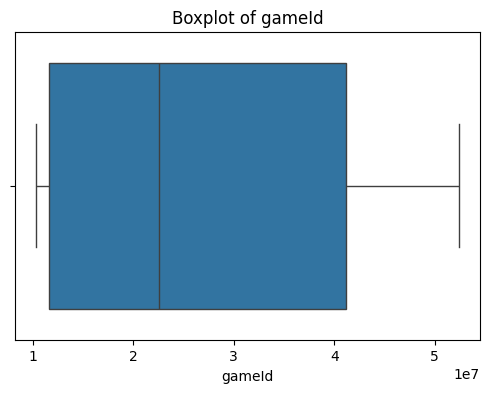

personId


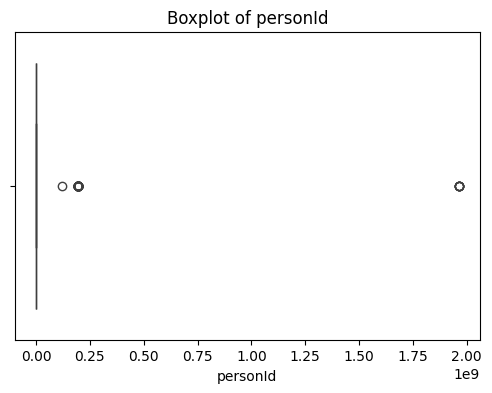

astPct


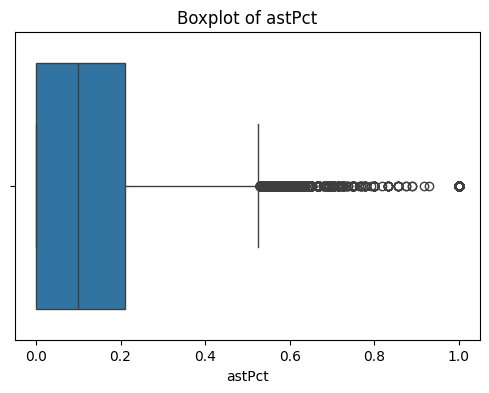

astTo


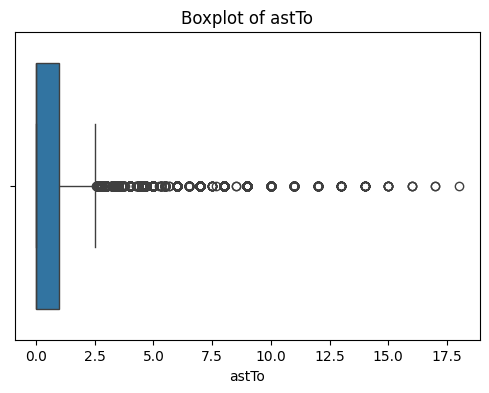

defRating


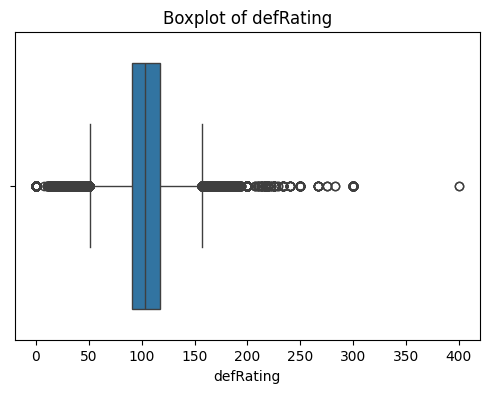

drebPct


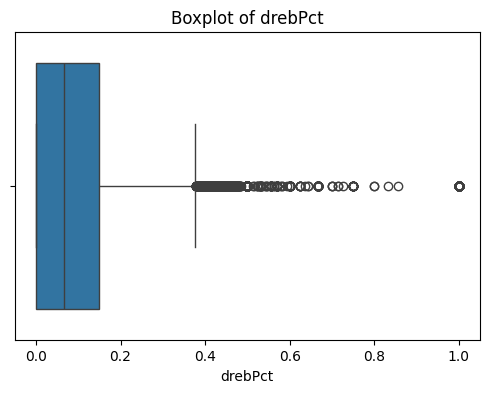

eDefRating


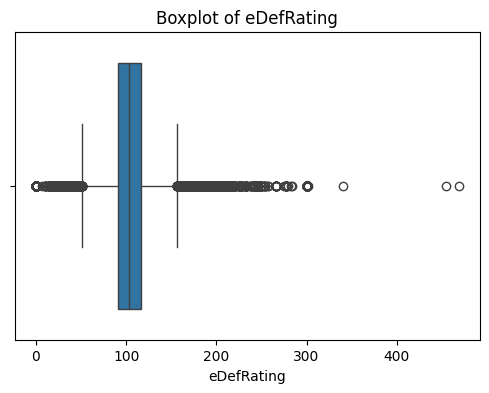

eNetRating


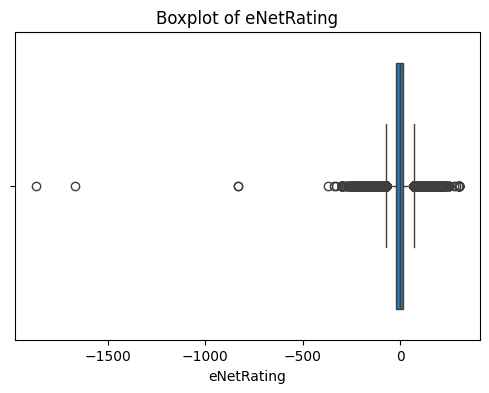

eOffRating


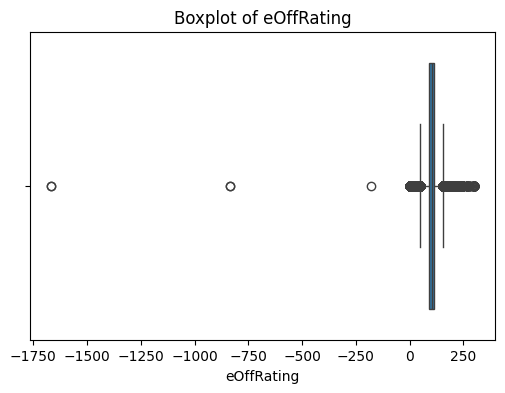

ePace


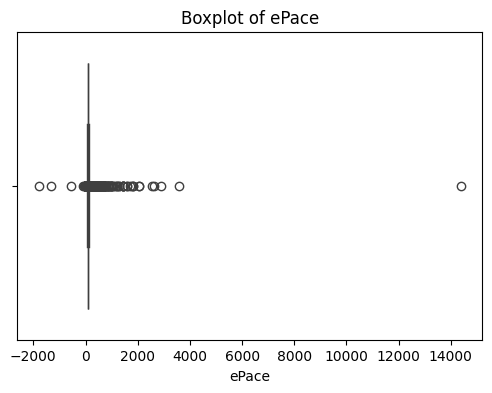

eTovPct


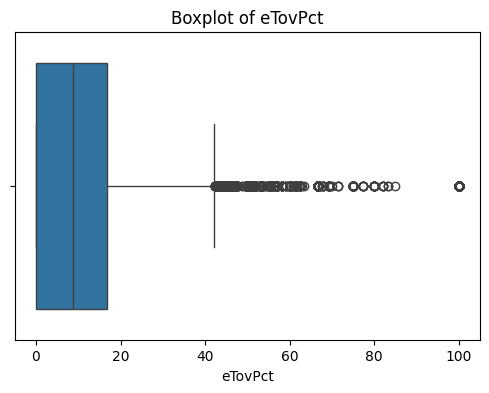

eUsgPct


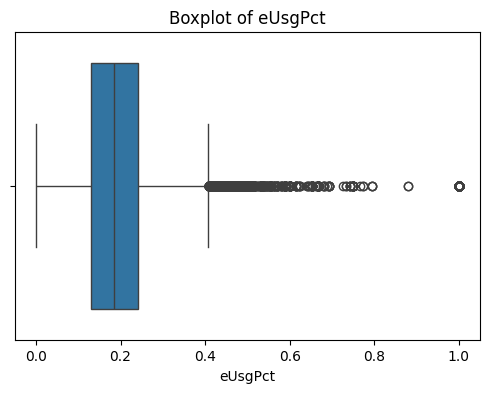

efgPct


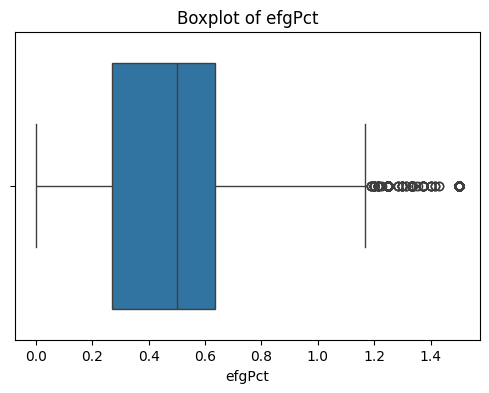

fgPct


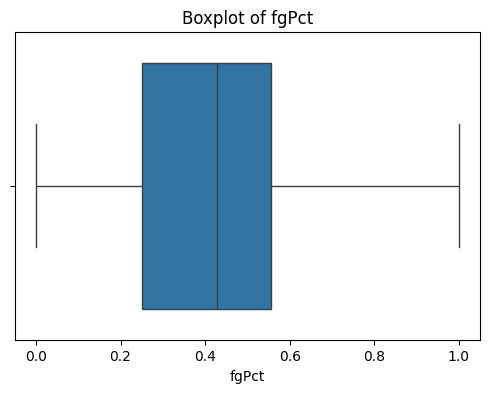

fga


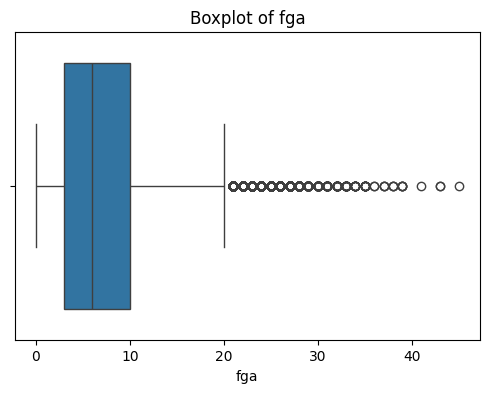

fgaPg


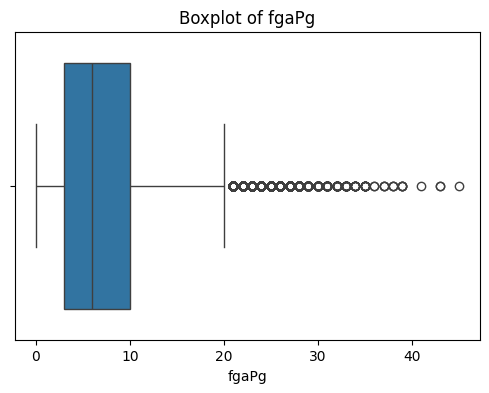

fgm


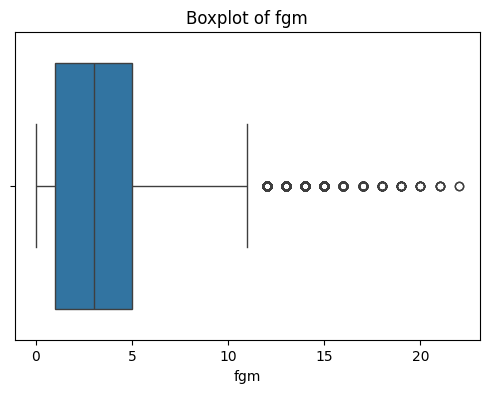

fgmPg


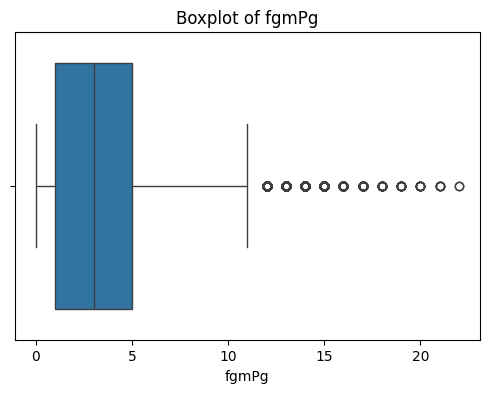

home


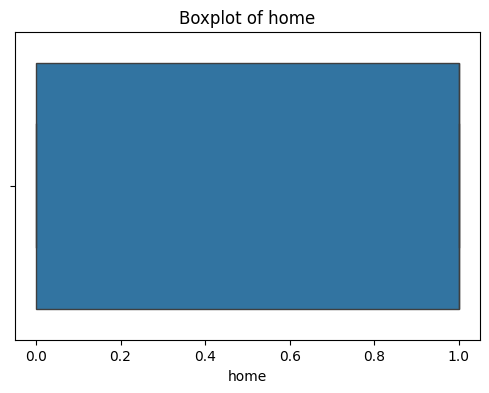

min


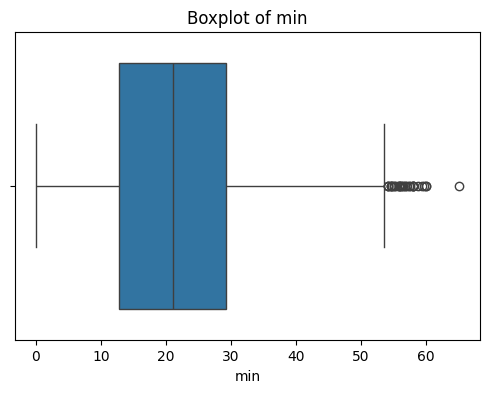

netRating


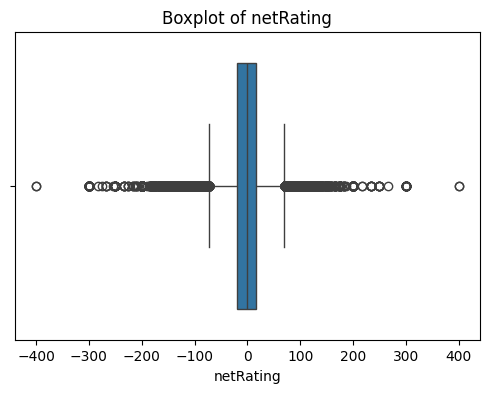

offRating


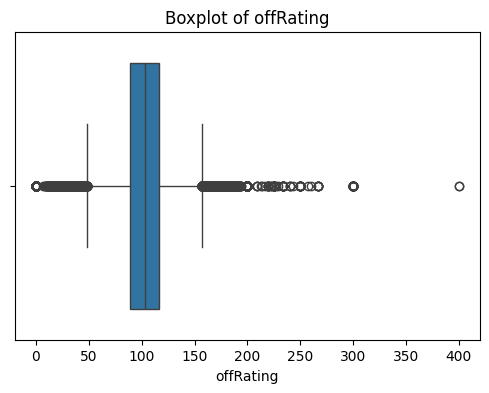

orebPct


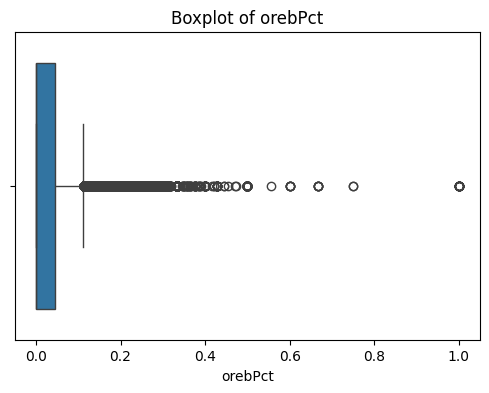

pace


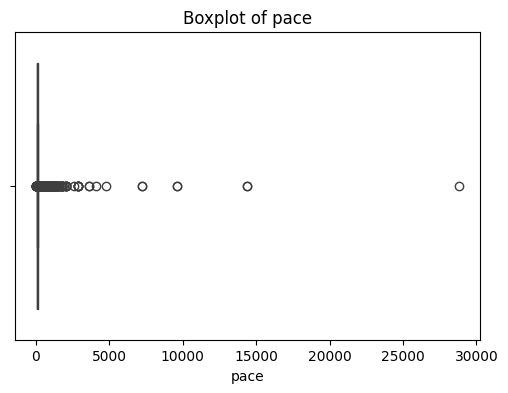

pacePer40


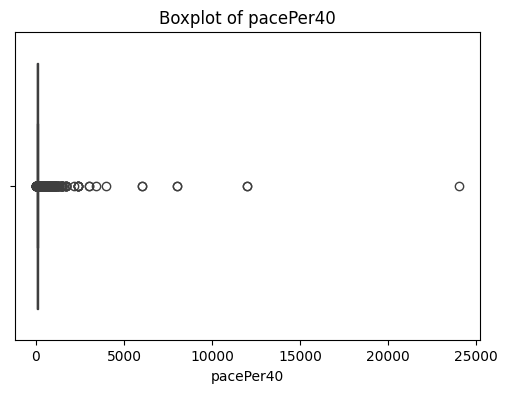

pie


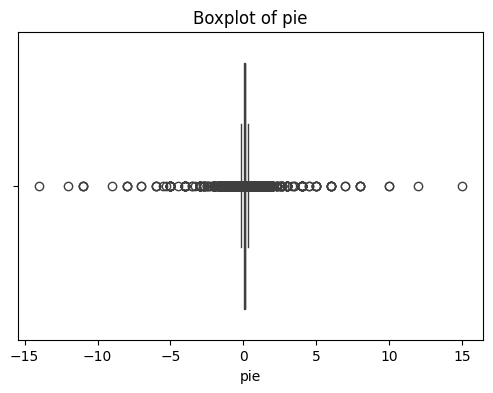

poss


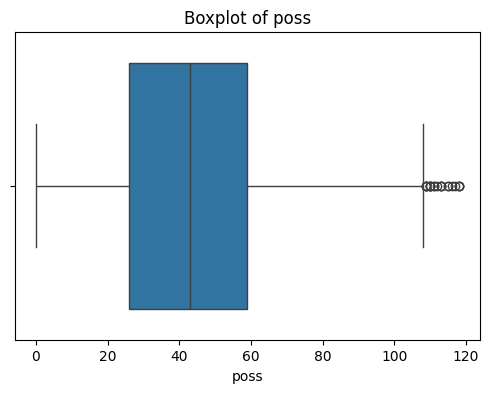

rebPct


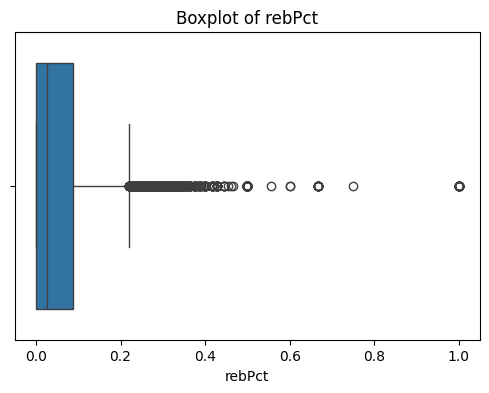

sp_work_DEF_RATING


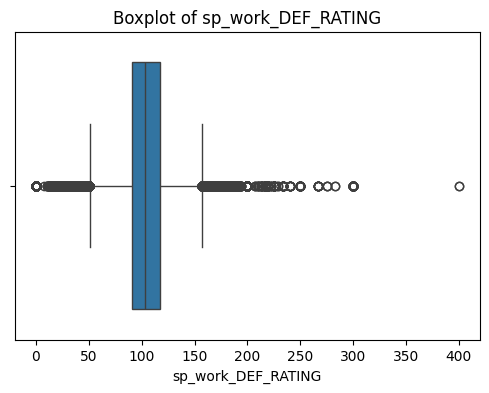

sp_work_DEF_RATING_RANK


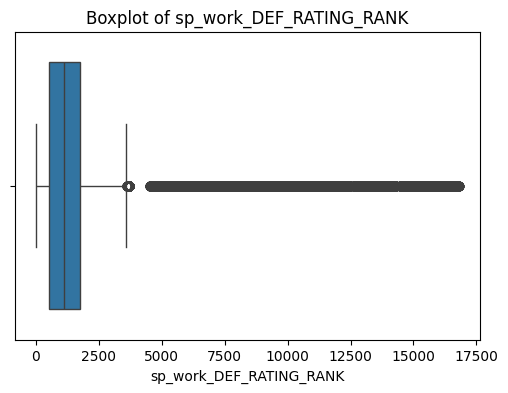

sp_work_NET_RATING


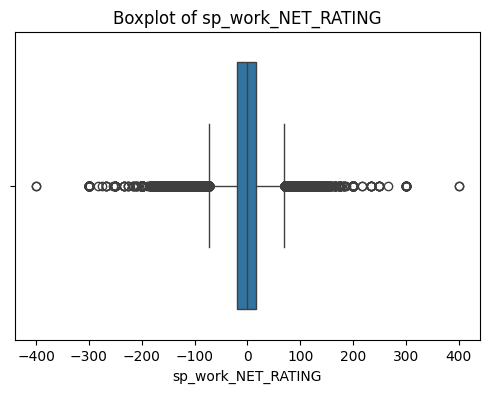

sp_work_NET_RATING_RANK


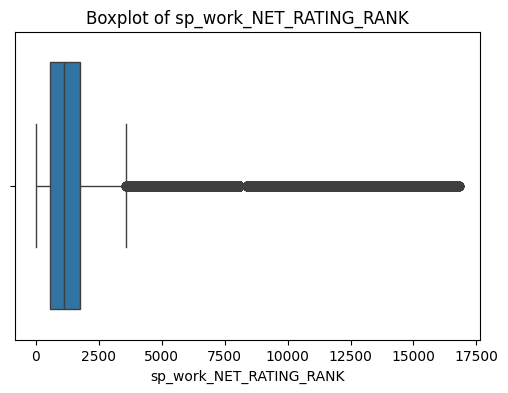

sp_work_OFF_RATING


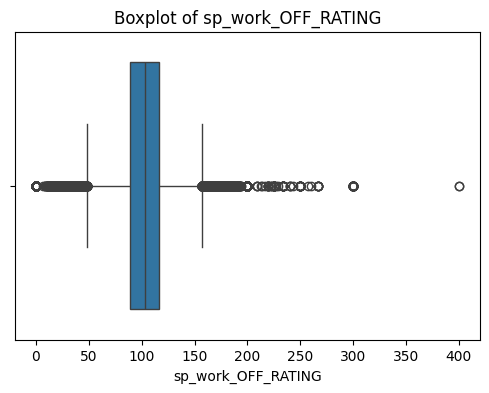

sp_work_OFF_RATING_RANK


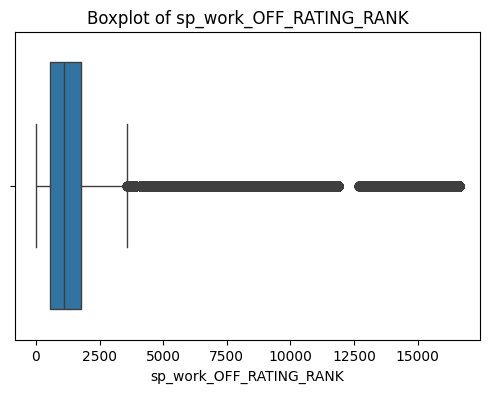

sp_work_PACE


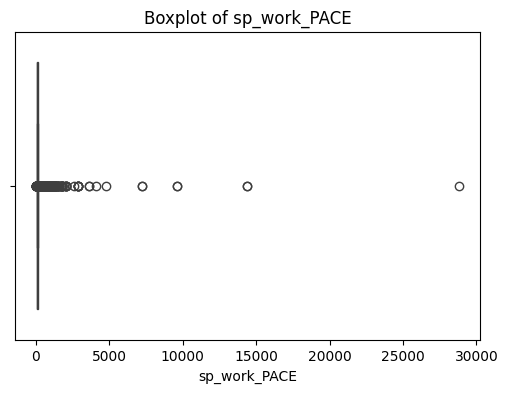

sp_work_PACE_RANK


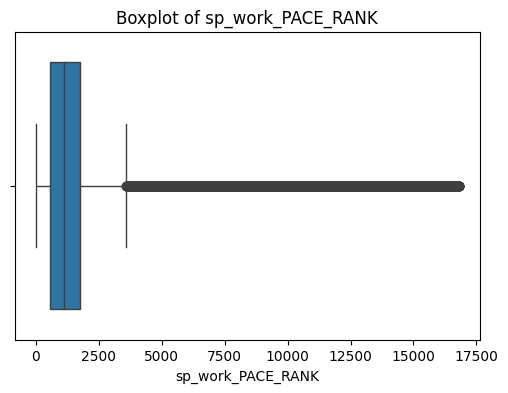

teamCount


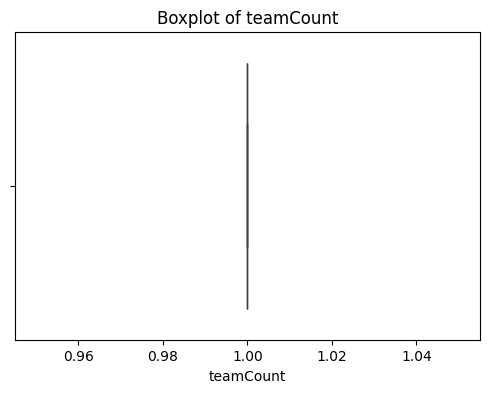

teamId


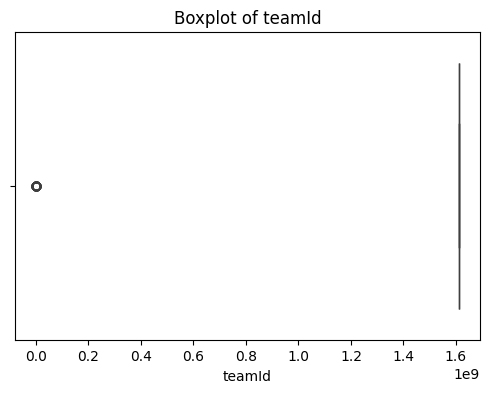

tmTovPct


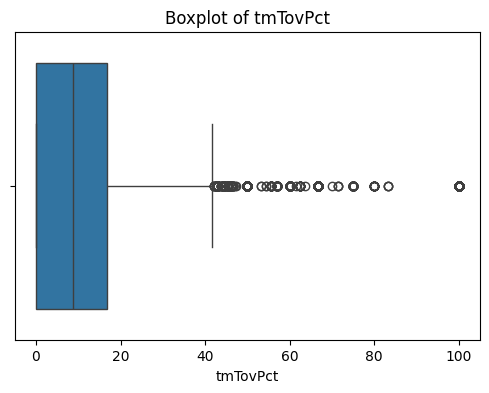

tsPct


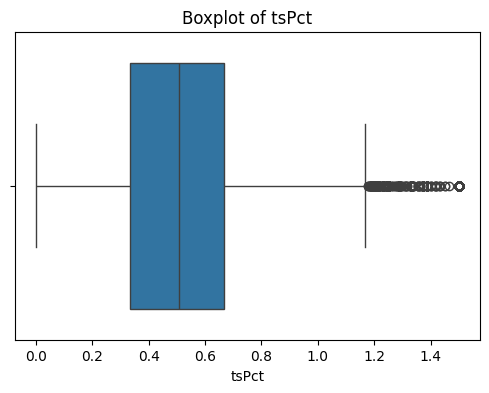

usgPct


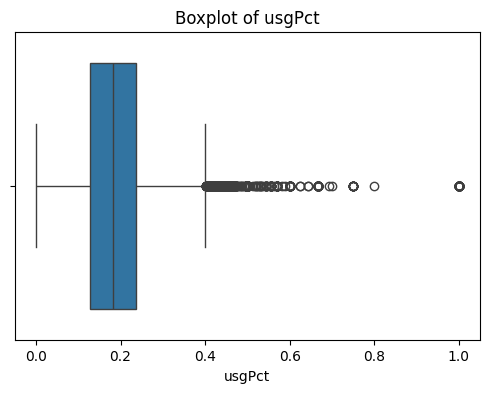

win


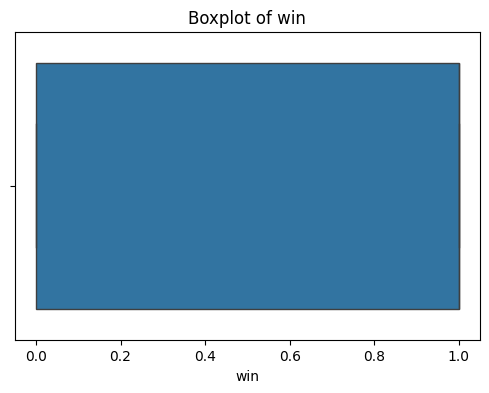

In [47]:
numeric_cols = df_players_stats.select(cs.numeric()).columns

for col in numeric_cols:
    # Boxplot
    print(col)
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_players_stats[col])
    plt.title(f'Boxplot of {col}')
    plt.show()